In [1]:
#%pip install ipywidgets
#%pip install metrics

# Imported libraries

In [2]:
import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from torchsummary import summary

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


# Data paths 

In [3]:

DATA_DIR = r'C:\inten\FT_Methods_for_Fetal_Head_Segmentation-main\dataset'
x_train_dir = os.path.join(DATA_DIR, 'train', 'images')
y_train_dir = os.path.join(DATA_DIR, 'train', 'masks')
x_valid_dir = os.path.join(DATA_DIR, 'val', 'images')
y_valid_dir = os.path.join(DATA_DIR, 'val', 'masks')
x_test_dir  = os.path.join(DATA_DIR, 'test', 'images')
select_class_gray_values = [255]


In [4]:
import matplotlib as plt

def visualize(**images):
    n = len(images)
    plt.figure(figsize=(5*n, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.title(name)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.axis('off')
    plt.show()

# Dataset

In [5]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from glob import glob
import os

def fill_mask_border(mask):
    """Fill the white ellipse border in a binary mask to create a solid region."""
    mask = (mask * 255).astype(np.uint8) if mask.max() <= 1 else mask.copy()
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(mask)
    cv2.drawContours(filled_mask, contours, -1, color=255, thickness=cv2.FILLED)
    return (filled_mask / 255).astype(np.float32)

class FetalHeadDataset(Dataset):
    def __init__(self, images_dir, masks_dir, class_gray_values, augmentation=None, preprocessing=None):
        self.image_paths = sorted(glob(os.path.join(images_dir, '*')))
        self.mask_paths  = sorted(glob(os.path.join(masks_dir, '*')))
        self.class_gray_values = class_gray_values
        self.augmentation = augmentation
        self.preprocessing = preprocessing

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, i):
        image = cv2.imread(self.image_paths[i], cv2.IMREAD_GRAYSCALE)
        mask  = cv2.imread(self.mask_paths[i],  cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise FileNotFoundError(f"Image not found: {self.image_paths[i]}")
        if mask is None:
            raise FileNotFoundError(f"Mask not found: {self.mask_paths[i]}")

        # Normalize image
        image = image.astype('float32') / 255.0

        # Fill ellipse in mask
        mask = fill_mask_border(mask)

        # Optional: filter to specific classes if needed
        if self.class_gray_values:
            mask = np.isin(mask * 255, self.class_gray_values).astype('float32')  # Recheck gray value logic
        else:
            mask = mask.astype('float32')

        image = np.expand_dims(image, -1)
        mask  = np.expand_dims(mask, -1)

        if self.augmentation:
            augmented = self.augmentation(image=image, mask=mask)
            image, mask = augmented['image'], augmented['mask']

        if self.preprocessing:
            processed = self.preprocessing(image=image, mask=mask)
            image, mask = processed['image'], processed['mask']

        if isinstance(mask, torch.Tensor):
            if mask.ndim == 4 and mask.shape[-1] == 1:
                mask = mask.squeeze(-1)
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
            if mask.ndim == 3 and mask.shape[0] != 1 and mask.shape[-1] == 1:
                mask = mask.permute(2, 0, 1)
        elif isinstance(mask, np.ndarray):
            if mask.ndim == 4 and mask.shape[-1] == 1:
                mask = np.squeeze(mask, axis=-1)
            if mask.ndim == 2:
                mask = np.expand_dims(mask, 0)
            if mask.ndim == 3 and mask.shape[0] != 1 and mask.shape[-1] == 1:
                mask = np.transpose(mask, (2, 0, 1))
            mask = torch.from_numpy(mask).float()

        assert mask.shape == (1, 256, 256), f"Mask shape: {mask.shape}"

        if isinstance(image, torch.Tensor):
            if image.ndim == 4 and image.shape[-1] == 1:
                image = image.squeeze(-1)
            if image.ndim == 2:
                image = image.unsqueeze(0)
            if image.ndim == 3 and image.shape[0] != 1 and image.shape[-1] == 1:
                image = image.permute(2, 0, 1)
        elif isinstance(image, np.ndarray):
            if image.ndim == 4 and image.shape[-1] == 1:
                image = np.squeeze(image, axis=-1)
            if image.ndim == 2:
                image = np.expand_dims(image, 0)
            if image.ndim == 3 and image.shape[0] != 1 and image.shape[-1] == 1:
                image = np.transpose(image, (2, 0, 1))
            image = torch.from_numpy(image).float()

        assert image.shape == (1, 256, 256), f"Image shape: {image.shape}"

        return image, mask


# Augumentation


In [6]:
def get_training_augmentation():
    return A.Compose([
        A.PadIfNeeded(256, 256),
        A.RandomCrop(256, 256),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(p=0.15),
        A.GaussNoise(var_limit=(10.0,50.0), p=0.1),
    ])

def get_validation_augmentation():
    return A.Compose([
        A.PadIfNeeded(256,256),
        A.CenterCrop(256,256)
    ])

def get_preprocessing():
    return A.Compose([
        A.Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=1.0),
        ToTensorV2()
    ])

In [7]:
BATCH_SIZE = 8
NUM_WORKERS = 0

train_dataset = FetalHeadDataset(
    x_train_dir, y_train_dir,
    class_gray_values=select_class_gray_values,
    augmentation=get_training_augmentation(),
    preprocessing=get_preprocessing()
)
val_dataset = FetalHeadDataset(
    x_valid_dir, y_valid_dir,
    class_gray_values=select_class_gray_values,
    augmentation=get_validation_augmentation(),
    preprocessing=get_preprocessing()
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)


In [8]:
ENCODER = "resnet34"
ENCODER_WEIGHTS = "imagenet"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=1,
    classes=1,
    activation=None
).to(DEVICE)
summary(model, input_size=(1, 256, 256), batch_size=BATCH_SIZE)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [8, 64, 128, 128]           3,136
       BatchNorm2d-2          [8, 64, 128, 128]             128
              ReLU-3          [8, 64, 128, 128]               0
         MaxPool2d-4            [8, 64, 64, 64]               0
            Conv2d-5            [8, 64, 64, 64]          36,864
       BatchNorm2d-6            [8, 64, 64, 64]             128
              ReLU-7            [8, 64, 64, 64]               0
            Conv2d-8            [8, 64, 64, 64]          36,864
       BatchNorm2d-9            [8, 64, 64, 64]             128
             ReLU-10            [8, 64, 64, 64]               0
       BasicBlock-11            [8, 64, 64, 64]               0
           Conv2d-12            [8, 64, 64, 64]          36,864
      BatchNorm2d-13            [8, 64, 64, 64]             128
             ReLU-14            [8, 64,

In [9]:
'''model = UNet(in_channels=1, out_channels=1).to(DEVICE)
print('Number of parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))'''


"model = UNet(in_channels=1, out_channels=1).to(DEVICE)\nprint('Number of parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))"

In [10]:
from segmentation_models_pytorch.losses import FocalLoss
import segmentation_models_pytorch as smp
import torch
import numpy as np
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
    
    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)  # Needed because you use logits
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        smooth = 1.
        intersection = (inputs * targets).sum()
        dice = (2.*intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
        return 1 - dice + self.bce(inputs, targets)


# Optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=4, factor=0.5, min_lr=1e-6)

# Helper metric functions
def safe_div(numerator, denominator):
    return (numerator + 1e-7) / (denominator + 1e-7) if denominator != 0 else 0.0


In [11]:
def iou_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    intersection = (outputs * labels).sum()
    union = (outputs + labels).clamp(0, 1).sum()
    return safe_div(intersection, union)

def dice_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    intersection = (outputs * labels).sum()
    total = outputs.sum() + labels.sum()
    return safe_div(2 * intersection, total)

def precision_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    tp = (outputs * labels).sum()
    fp = (outputs * (1 - labels)).sum()
    return safe_div(tp, tp + fp)

def recall_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    tp = (outputs * labels).sum()
    fn = ((1 - outputs) * labels).sum()
    return safe_div(tp, tp + fn)

def accuracy_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    correct = (outputs == labels).float().sum()
    total = torch.numel(outputs)
    return safe_div(correct, total)

def f1_score_pytorch(outputs, labels, threshold=0.5):
    prec = precision_pytorch(outputs, labels, threshold)
    rec = recall_pytorch(outputs, labels, threshold)
    return safe_div(2 * prec * rec, prec + rec)

In [ ]:
def train_epoch(loader, model, loss_fn, optimizer, device):
    model.train()
    metrics = {'loss': 0, 'iou': 0, 'dice': 0, 'precision': 0, 'recall': 0, 'accuracy': 0, 'f1': 0}
    for images, masks in tqdm(loader):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss_fn = DiceBCELoss()
        loss = loss_fn(logits, masks)
        loss.backward()
        optimizer.step()
        probs = torch.sigmoid(logits)

        metrics['loss'] += loss.item()
        metrics['iou'] += iou_pytorch(probs, masks)
        metrics['dice'] += dice_pytorch(probs, masks)
        metrics['precision'] += precision_pytorch(probs, masks)
        metrics['recall'] += recall_pytorch(probs, masks)
        metrics['accuracy'] += accuracy_pytorch(probs, masks)
        metrics['f1'] += f1_score_pytorch(probs, masks)

    n = len(loader)
    return {k: v / n for k, v in metrics.items()}

def eval_epoch(loader, model, loss_fn, device):
    model.eval()
    metrics = {'loss': 0, 'iou': 0, 'dice': 0, 'precision': 0, 'recall': 0, 'accuracy': 0, 'f1': 0}
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            logits = model(images)
            loss_fn = DiceBCELoss()
            loss = loss_fn(logits, masks)
            probs = torch.sigmoid(logits)

            metrics['loss'] += loss.item()
            metrics['iou'] += iou_pytorch(probs, masks)
            metrics['dice'] += dice_pytorch(probs, masks)
            metrics['precision'] += precision_pytorch(probs, masks)
            metrics['recall'] += recall_pytorch(probs, masks)
            metrics['accuracy'] += accuracy_pytorch(probs, masks)
            metrics['f1'] += f1_score_pytorch(probs, masks)

    n = len(loader)
    return {k: v / n for k, v in metrics.items()}

In [13]:
NUM_EPOCHS = 100
PATIENCE = 25  # stop if no improvement after 25 epochs
counter = 0

best_val_iou, best_epoch = 0, 0
best_model_path = os.path.join(DATA_DIR, 'best_model_resnet.pth')

log = {
    'train_loss': [], 'val_loss': [],
    'train_iou': [], 'val_iou': [],
    'train_dice': [], 'val_dice': [],
    'train_precision': [], 'val_precision': [],
    'train_accuracy': [], 'val_accuracy': [],
    'train_recall': [], 'val_recall': [],
    'train_f1': [], 'val_f1': []
}

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    # Training
    train_metrics = train_epoch(train_loader, model, DiceBCELoss, optimizer, DEVICE)

    # Validation
    val_metrics = eval_epoch(val_loader, model, DiceBCELoss, DEVICE)

    # Scheduler step
    lr_scheduler.step(val_metrics['loss'])

    # Logging
    print(f"Train Loss: {train_metrics['loss']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    print(f"Train IoU: {train_metrics['iou']:.4f} | Val IoU: {val_metrics['iou']:.4f}")
    print(f"Train Dice: {train_metrics['dice']:.4f} | Val Dice: {val_metrics['dice']:.4f}")
    print(f"Train Precision: {train_metrics['precision']:.4f} | Val Precision: {val_metrics['precision']:.4f}")
    print(f"Train Accuracy: {train_metrics['accuracy']:.4f} | Val Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Train Recall: {train_metrics['recall']:.4f} | Val Recall: {val_metrics['recall']:.4f}")
    print(f"Train F1: {train_metrics['f1']:.4f} | Val F1: {val_metrics['f1']:.4f}")

    for key in log.keys():
        metric_name = key.split('_', 1)[1]
        if key.startswith('train_'):
            log[key].append(train_metrics[metric_name])
        else:
            log[key].append(val_metrics[metric_name])

    # Early Stopping & Save Best Model
    if val_metrics['iou'] > best_val_iou:
        best_val_iou, best_epoch = val_metrics['iou'], epoch
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ Best checkpoint saved at epoch {epoch+1} with Val IoU: {best_val_iou:.4f}")
        counter = 0  # reset counter if improved
    else:
        counter += 1
        print(f"⏳ No improvement for {counter} epoch(s).")

    if counter >= PATIENCE:
        print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
        break

# Final summary
print(f"\n🏁 Best Val IoU: {best_val_iou:.4f} at epoch {best_epoch+1}")



Epoch 1/100


100%|██████████| 100/100 [00:17<00:00,  5.87it/s]


Train Loss: 0.8905 | Val Loss: 0.5039
Train IoU: 0.6676 | Val IoU: 0.8954
Train Dice: 0.7945 | Val Dice: 0.9358
Train Precision: 0.7615 | Val Precision: 0.9661
Train Accuracy: 0.7559 | Val Accuracy: 0.9089
Train Recall: 0.8496 | Val Recall: 0.9264
Train F1: 0.7945 | Val F1: 0.9358
✅ Best checkpoint saved at epoch 1 with Val IoU: 0.8954

Epoch 2/100


100%|██████████| 100/100 [00:17<00:00,  5.66it/s]


Train Loss: 0.7104 | Val Loss: 0.4316
Train IoU: 0.8020 | Val IoU: 0.9476
Train Dice: 0.8877 | Val Dice: 0.9659
Train Precision: 0.8806 | Val Precision: 0.9740
Train Accuracy: 0.8753 | Val Accuracy: 0.9604
Train Recall: 0.9060 | Val Recall: 0.9708
Train F1: 0.8877 | Val F1: 0.9659
✅ Best checkpoint saved at epoch 2 with Val IoU: 0.9476

Epoch 3/100


...

Train Loss: 0.5322 | Val Loss: 0.3758
Train IoU: 0.9377 | Val IoU: 0.9758
Train Dice: 0.9673 | Val Dice: 0.9847
Train Precision: 0.9684 | Val Precision: 0.9889
Train Accuracy: 0.9653 | Val Accuracy: 0.9801
Train Recall: 0.9674 | Val Recall: 0.9868
Train F1: 0.9673 | Val F1: 0.9847
⏳ No improvement for 23 epoch(s).

Epoch 72/100


100%|██████████| 100/100 [00:19<00:00,  5.07it/s]


Train Loss: 0.5298 | Val Loss: 0.3790
Train IoU: 0.9374 | Val IoU: 0.9729
Train Dice: 0.9668 | Val Dice: 0.9828
Train Precision: 0.9686 | Val Precision: 0.9891
Train Accuracy: 0.9640 | Val Accuracy: 0.9776
Train Recall: 0.9672 | Val Recall: 0.9837
Train F1: 0.9668 | Val F1: 0.9828
⏳ No improvement for 24 epoch(s).

Epoch 73/100


100%|██████████| 100/100 [00:18<00:00,  5.33it/s]


Train Loss: 0.5280 | Val Loss: 0.3767
Train IoU: 0.9405 | Val IoU: 0.9750
Train Dice: 0.9686 | Val Dice: 0.9842
Train Precision: 0.9696 | Val Precision: 0.9890
Train Accuracy: 0.9663 | Val Accuracy: 0.9793
Train Recall: 0.9693 | Val Recall: 0.9859
Train F1: 0.9686 | Val F1: 0.9842
⏳ No improvement for 25 epoch(s).

🛑 Early stopping triggered at epoch 73

🏁 Best Val IoU: 0.9794 at epoch 48


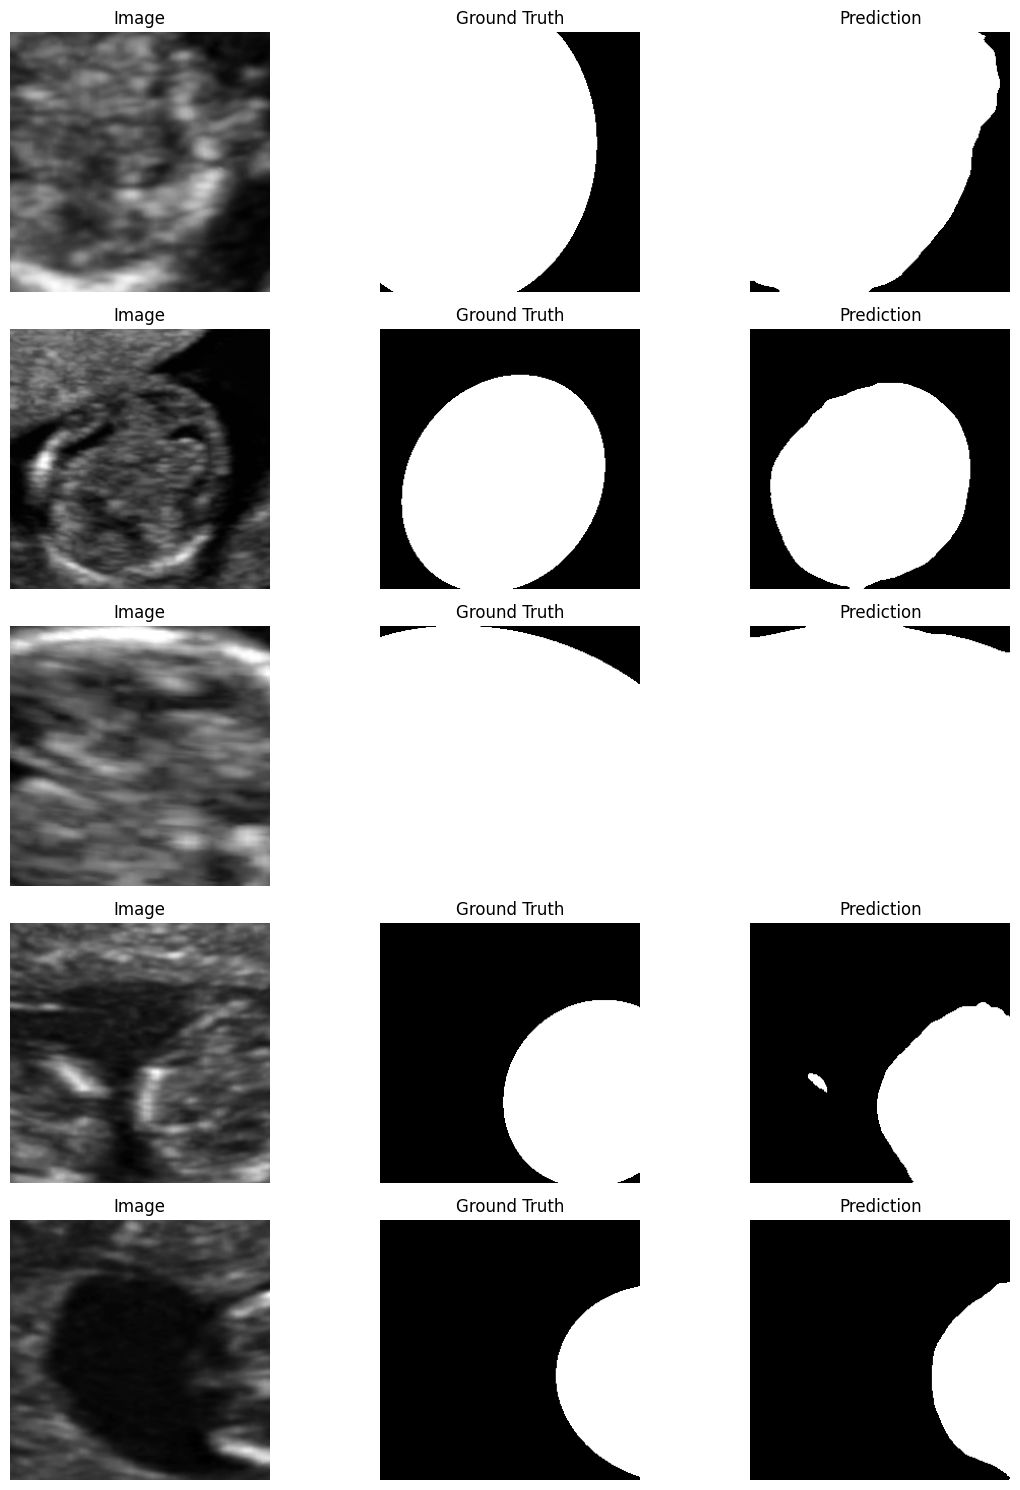

In [14]:
import matplotlib.pyplot as plt

# Load best model weights
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

# Show predictions on a few validation samples
n_samples = 5  # Number of images to visualize
fig, axs = plt.subplots(n_samples, 3, figsize=(12, n_samples * 3))

with torch.no_grad():
    for i in range(n_samples):
        # Get image and mask from validation dataset
        img, mask = val_dataset[i]
        img_input = img.unsqueeze(0).to(DEVICE)

        # Predict
        pred = torch.sigmoid(model(img_input))
        pred_mask = (pred[0, 0].cpu().numpy() > 0.5)

        # Plot
        axs[i, 0].imshow(img[0].cpu(), cmap='gray')
        axs[i, 0].set_title("Image")
        axs[i, 0].axis('off')

        axs[i, 1].imshow(mask[0].cpu(), cmap='gray')
        axs[i, 1].set_title("Ground Truth")
        axs[i, 1].axis('off')

        axs[i, 2].imshow(pred_mask, cmap='gray')
        axs[i, 2].set_title("Prediction")
        axs[i, 2].axis('off')

plt.tight_layout()
plt.show()


In [15]:
import matplotlib.pyplot as plt
import torch

def to_numpy(x):
    """Convert tensor to numpy, handling GPU tensors."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return x

def plot_training_history(log):
    metrics = [
        ("loss", "Loss"),
        ("iou", "IoU"),
        ("dice", "Dice"),
        ("precision", "Precision"),
        ("recall", "Recall"),
        ("accuracy", "Accuracy"),
        ("f1", "F1 Score")
    ]

    fig, axes = plt.subplots(len(metrics), 1, figsize=(8, len(metrics) * 3))

    if len(metrics) == 1:
        axes = [axes]

    for ax, (key, title) in zip(axes, metrics):
        train_key = f"train_{key}"
        val_key = f"val_{key}"

        if train_key in log and val_key in log:
            train_vals = [to_numpy(v) for v in log[train_key]]
            val_vals = [to_numpy(v) for v in log[val_key]]

            ax.plot(train_vals, label=f"Train {title}", marker='o')
            ax.plot(val_vals, label=f"Val {title}", marker='o')
            ax.set_title(f"{title} over Epochs")
            ax.set_xlabel("Epoch")
            ax.set_ylabel(title)
            ax.grid(True)
            ax.legend()

    plt.tight_layout()
    plt.show()

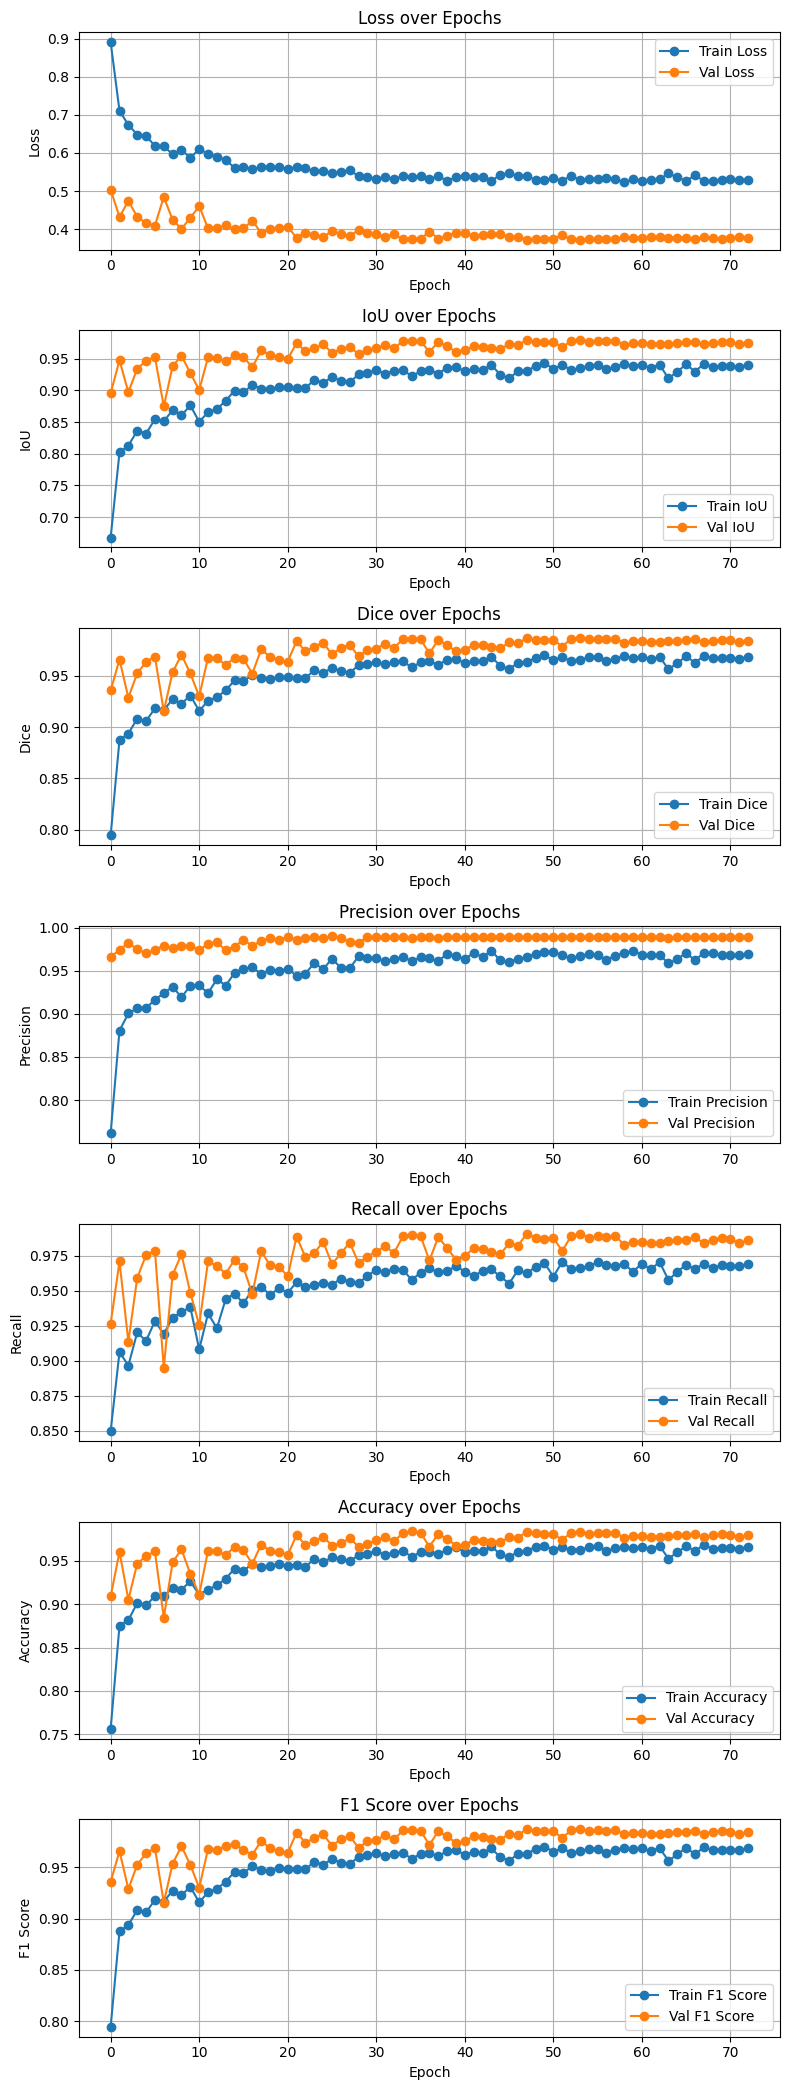

In [16]:
plot_training_history(log)

# testing

Using device: cuda
[✅] Results saved to: C:\inten\FT_Methods_for_Fetal_Head_Segmentation-main\test\predicted_masks_resnet
[📄] CSV saved as: C:\inten\FT_Methods_for_Fetal_Head_Segmentation-main\test\predicted_masks_resnet\head_circumference_results.csv

[🖼️] Displaying Results...


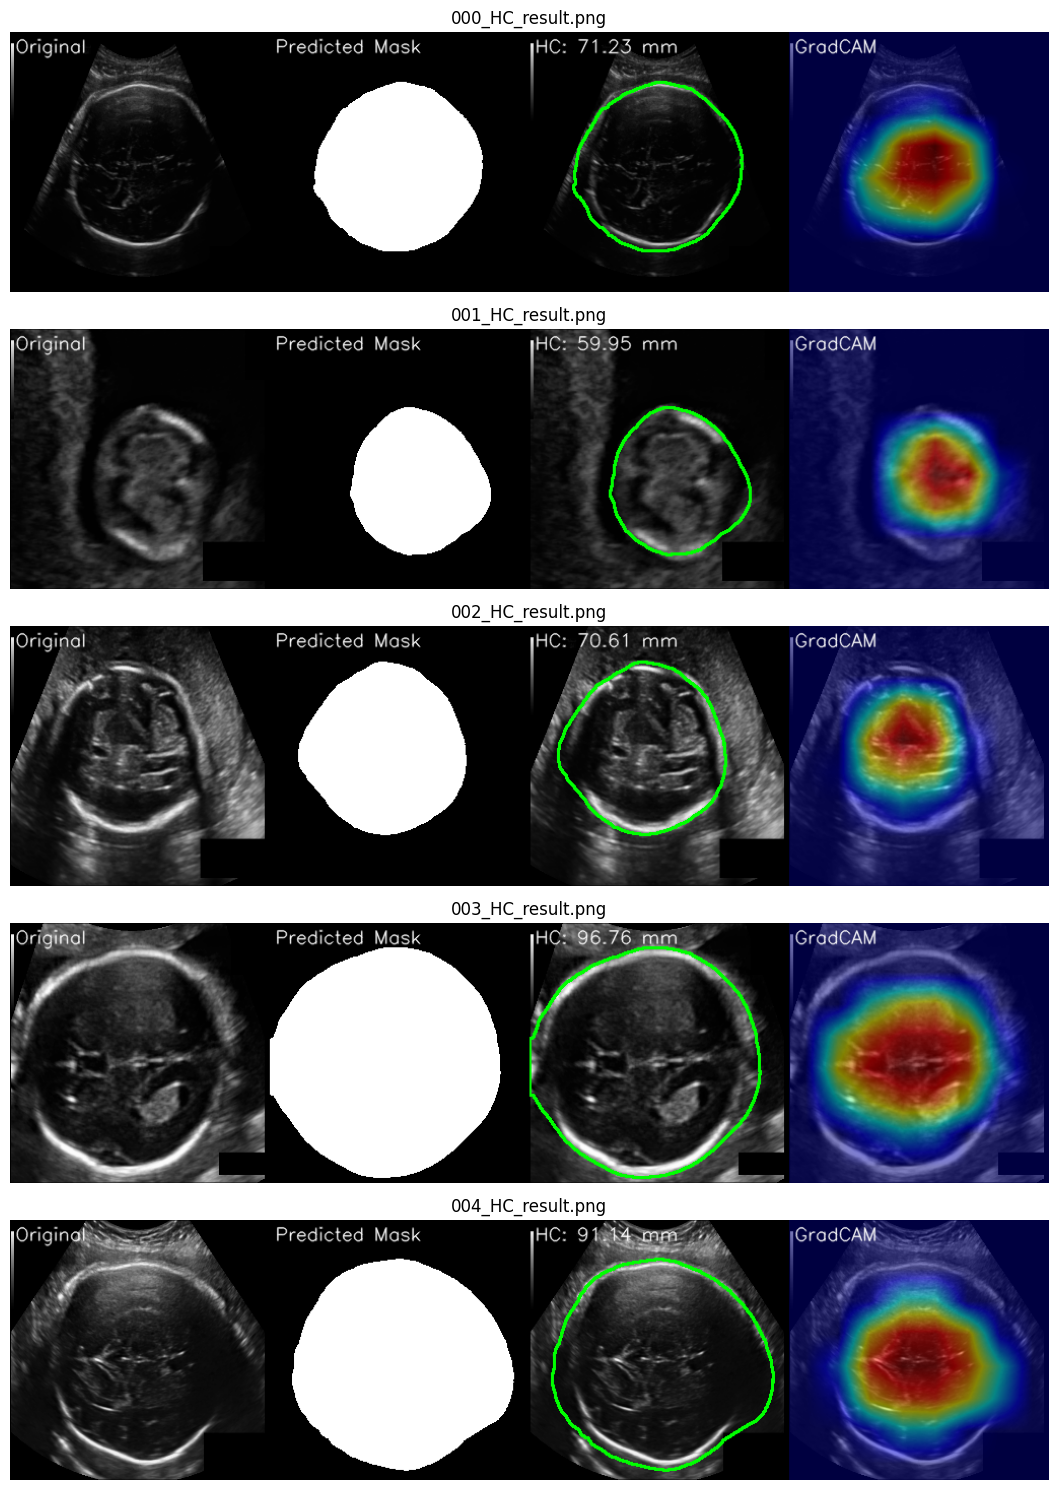

In [2]:
import os
import glob
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader, Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# --- Dataset Class ---
class TestDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths
        self.transform = A.Compose([
            A.Resize(256, 256),
            A.Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)
        augmented = self.transform(image=image)
        return augmented['image'], self.image_paths[idx]

# --- Clean Prediction ---
def clean_prediction_mask(mask_tensor, area_thresh=100):
    mask_np = mask_tensor.squeeze().cpu().numpy().astype(np.uint8)
    contours, _ = cv2.findContours(mask_np, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask_clean = np.zeros_like(mask_np)
    for cnt in contours:
        if cv2.contourArea(cnt) > area_thresh:
            cv2.drawContours(mask_clean, [cnt], -1, 1, thickness=cv2.FILLED)
    return torch.tensor(mask_clean).unsqueeze(0)

# --- HC Calculation ---
def calculate_head_circumference(mask_np, pixel_to_mm=0.13):
    contours, _ = cv2.findContours(mask_np, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        perimeter_px = cv2.arcLength(largest, True)
        return perimeter_px * pixel_to_mm, largest
    return 0, None

# --- GradCAM Hook ---
def apply_gradcam(model, input_tensor, target_layer):
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0].detach())

    def forward_hook(module, input, output):
        activations.append(output.detach())

    handle_fw = target_layer.register_forward_hook(forward_hook)
    handle_bw = target_layer.register_backward_hook(backward_hook)

    model.eval()
    output = model(input_tensor)
    pred_class = output.mean()
    model.zero_grad()
    pred_class.backward()

    gradients_ = gradients[0]
    activations_ = activations[0]

    weights = gradients_.mean(dim=(2, 3), keepdim=True)
    gradcam_map = F.relu((weights * activations_).sum(dim=1)).squeeze().cpu().numpy()
    gradcam_map = cv2.resize(gradcam_map, (256, 256))
    gradcam_map -= gradcam_map.min()
    gradcam_map /= gradcam_map.max() + 1e-8

    handle_fw.remove()
    handle_bw.remove()
    return gradcam_map

# --- Configs ---
DATA_DIR = r"C:\inten\FT_Methods_for_Fetal_Head_Segmentation-main\dataset"
IMAGE_DIR = r"C:\inten\FT_Methods_for_Fetal_Head_Segmentation-main\test\images"
SAVE_DIR = r"C:\inten\FT_Methods_for_Fetal_Head_Segmentation-main\test\predicted_masks_resnet"
MODEL_PATH = os.path.join(DATA_DIR, 'best_model_resnet.pth')
ENCODER = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# --- Load Model ---
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=1,
    classes=1
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

# --- Load Test Images ---
test_image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.png")))
test_dataset = TestDataset(test_image_paths)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# --- Store Results ---
results = []
saved_images = []  # To collect saved image paths for later visualization

# --- Inference Loop ---
for images, paths in test_loader:
    images = images.to(DEVICE)
    with torch.no_grad():
        preds = torch.sigmoid(model(images)) > 0.6

    cleaned_mask = clean_prediction_mask(preds[0])
    mask_np = cleaned_mask[0].cpu().numpy().astype(np.uint8)
    original_image = images[0][0].cpu().numpy()

    # HC Calculation
    hc_mm, contour = calculate_head_circumference(mask_np)

    # Prepare Images
    base_name = os.path.splitext(os.path.basename(paths[0]))[0]
    os.makedirs(SAVE_DIR, exist_ok=True)
    orig_resized = cv2.resize((original_image * 255).astype(np.uint8), (256, 256))
    orig_color = cv2.cvtColor(orig_resized, cv2.COLOR_GRAY2BGR)

    # Predicted Mask
    mask_vis = (mask_np * 255).astype(np.uint8)
    mask_vis = cv2.cvtColor(mask_vis, cv2.COLOR_GRAY2BGR)

    # Contour Overlay
    contour_img = orig_color.copy()
    if contour is not None:
        cv2.drawContours(contour_img, [contour], -1, (0, 255, 0), 2)

    # GradCAM
    target_layer = model.encoder.layer4[-1]
    gradcam_map = apply_gradcam(model, images, target_layer)
    gradcam_overlay = cv2.applyColorMap(np.uint8(255 * gradcam_map), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(orig_color, 0.5, gradcam_overlay, 0.5, 0)

    # Add Titles
    def add_title(img, title):
        return cv2.putText(img.copy(), title, (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1, cv2.LINE_AA)

    vis1 = add_title(orig_color, "Original")
    vis2 = add_title(mask_vis, "Predicted Mask")
    vis3 = add_title(contour_img, f"HC: {hc_mm:.2f} mm")
    vis4 = add_title(overlay, "GradCAM")

    # Concatenate all images into one row
    combined = np.concatenate([vis1, vis2, vis3, vis4], axis=1)
    result_path = os.path.join(SAVE_DIR, f"{base_name}_result.png")
    cv2.imwrite(result_path, combined)
    saved_images.append(result_path)

    # Append CSV result
    results.append({
        "Image": os.path.basename(paths[0]),
        "Head Circumference (mm)": round(hc_mm, 2)
    })

# --- Save Results to CSV ---
df = pd.DataFrame(results)
csv_path = os.path.join(SAVE_DIR, "head_circumference_results.csv")
df.to_csv(csv_path, index=False)
print(f"[✅] Results saved to: {SAVE_DIR}")
print(f"[📄] CSV saved as: {csv_path}")

# --- Final Visualization of All Results ---
print("\n[🖼️] Displaying Results...")
num_images = len(saved_images)
cols = 1
rows = min(5, num_images)  # Display up to 5 results at a time

plt.figure(figsize=(15, rows * 3))
for i, img_path in enumerate(saved_images[:rows]):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis('off')
plt.tight_layout()
plt.show()
